In [103]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   False,
    "legend.fontsize":  9,
})

In [122]:
import json
import pandas as pd
from pathlib import Path

FOLDER = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_fixed_trts_split_jsons")
USERS_TO_KEEP = ['P004', 'P104', 'P105', 'P121']

# Ablations where results are stored under 'result' key with ft subkeys
FT_ABLATIONS = {'A1', 'A2', 'A11'}  # head_only + full_ft structure

def infer_ablation_id(filename: str) -> str:
    parts = filename.split('_')
    if parts[0] == 'grid':
        if parts[1] == 'A2':
            return '_'.join(parts[:4])   # e.g. grid_A2_k5_n10
        return '_'.join(parts[:3])       # e.g. grid_k5_n10
    elif parts[0] == 'A5':
        return '_'.join(parts[:2])       # e.g. A5_E4
    else:
        return parts[0]                  # e.g. A1, A2, M0
    
def make_row(ablation_id: str, ft_label: str, user_accs: dict) -> dict:
    all_kept_accs = list(user_accs.values())
    return {
        'Ablation_ID':     ablation_id,
        'Finetune_Method': ft_label,
        **user_accs,
        'Mean':            pd.Series(all_kept_accs).mean(),
        'Median':          pd.Series(all_kept_accs).median(),
        'Std':             pd.Series(all_kept_accs).std(),
    }
    
def parse_top_level_ft_file(data: dict, ablation_id: str) -> list[dict]:
    """For A7: ft keys live at top level with per_subject_head_acc / per_subject_full_acc."""
    rows = []
    for key, ft_label in [('per_subject_head_acc', 'head'), ('per_subject_full_acc', 'full')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_maml_file(data: dict, ablation_id: str) -> list[dict]:
    """For A8: MAML result lives at top level under per_subject_mean."""
    rows = []
    for key, ft_label in [('per_subject_mean', 'MAML')]:
        per_user = data[key]
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_ft_file(result: dict, ablation_id: str) -> list[dict]:
    """For FT_ABLATIONS (A1, A2, A11): ft keys live under data['result'] with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = result[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_top_level_ft_per_user_file(data: dict, ablation_id: str) -> list[dict]:
    """For grid_A2_kx: ft keys live at top level (not under 'result') with per_user_acc subkey."""
    rows = []
    for ft_key, ft_label in [('test_head_only', 'head'), ('test_full_ft', 'full')]:
        ft_data = data[ft_key]
        per_user = ft_data['per_user_acc']
        user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
        rows.append(make_row(ablation_id, ft_label, user_accs))
    return rows

def parse_maml_file(result: dict, ablation_id: str) -> list[dict]:
    per_user = result['per_user_acc']
    user_accs = {pid: per_user[pid] for pid in USERS_TO_KEEP}
    return [make_row(ablation_id, 'MAML', user_accs)]

rows = []
for json_file in sorted(FOLDER.glob("*.json")):
    ablation_id = infer_ablation_id(json_file.name)

    with open(json_file) as f:
        data = json.load(f)

    if ablation_id in FT_ABLATIONS:
        result = data['result']
        rows.extend(parse_ft_file(result, ablation_id))
    elif ablation_id == 'A7':
        rows.extend(parse_top_level_ft_file(data, ablation_id))
    elif ablation_id == 'A8':
        rows.extend(parse_top_level_maml_file(data, ablation_id))
    elif ablation_id.startswith('grid_A2'):
        # Top-level ft structure (test_head_only / test_full_ft) with per_user_acc subkey
        rows.extend(parse_top_level_ft_per_user_file(data, ablation_id))
    else:
        # A5 and remaining grids use 'test_results'; A4, M0, and others use 'result'
        if ablation_id.startswith('A5') or ablation_id.startswith('grid'):
            result = data['test_results']
        elif ablation_id == 'A4':
            result = data['fold_results'][0]['test_results']
        elif ablation_id == 'M0':
            result = data['result']['test_results']
        else:
            result = data['result']
        rows.extend(parse_maml_file(result, ablation_id))

df = pd.DataFrame(rows, columns=['Ablation_ID', 'Finetune_Method'] + USERS_TO_KEEP + ['Mean', 'Median', 'Std'])
print(df.shape)
df.head(100)

(46, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A1,head,0.775583,0.799000,0.721833,0.807667,0.776021,0.787292,0.038583
3,A1,full,0.935333,0.885333,0.902750,0.906500,0.907479,0.904625,0.020733
4,A2,head,0.772500,0.784083,0.762417,0.701833,0.755208,0.767458,0.036668
5,A2,full,0.937417,0.903000,0.914083,0.936333,0.922708,0.925208,0.016978
6,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
7,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
8,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
9,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708


In [123]:
mask_a5   = df['Ablation_ID'].str.startswith('A5')
mask_grid = df['Ablation_ID'].str.startswith('grid')

In [124]:
df_a5   = df[mask_a5].reset_index(drop=True)
print(df_a5.shape)
df_a5.head(20)

(8, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A5_E12,MAML,0.924417,0.886417,0.875250,0.907750,0.898458,0.897083,0.021938
1,A5_E16,MAML,0.922167,0.885000,0.875250,0.908083,0.897625,0.896542,0.021383
2,A5_E20,MAML,0.926333,0.851417,0.904333,0.918333,0.900104,0.911333,0.033708
3,A5_E24,MAML,0.973833,0.881000,0.896000,0.945667,0.924125,0.920833,0.043150
4,A5_E32,MAML,0.885250,0.860500,0.850833,0.882000,0.869646,0.871250,0.016670
5,A5_E40,MAML,0.899750,0.888000,0.841750,0.880750,0.877563,0.884375,0.025126
6,A5_E4,MAML,0.842333,0.814250,0.827167,0.829500,0.828313,0.828333,0.011505
7,A5_E8,MAML,0.937917,0.913083,0.923333,0.918917,0.923312,0.921125,0.010603


In [125]:
df_grid = df[mask_grid].reset_index(drop=True)
print(df_grid.shape)
df_grid.head(100)

(27, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,grid_A2_k1_n10,head,0.425556,0.406311,0.412578,0.346644,0.397772,0.409444,0.035015
1,grid_A2_k1_n10,full,0.754644,0.638244,0.599956,0.662889,0.663933,0.650567,0.065784
2,grid_A2_k1_n3,head,0.760222,0.746593,0.777556,0.647037,0.732852,0.753407,0.058596
3,grid_A2_k1_n3,full,0.920074,0.892370,0.906963,0.915333,0.908685,0.911148,0.012152
4,grid_A2_k1_n5,head,0.639156,0.590444,0.644178,0.520222,0.598500,0.614800,0.057537
5,grid_A2_k1_n5,full,0.860089,0.797556,0.799333,0.836800,0.823444,0.818067,0.030402
6,grid_A2_k3_n10,head,0.494286,0.429457,0.479343,0.419571,0.455664,0.454400,0.036705
7,grid_A2_k3_n10,full,0.925229,0.810057,0.722971,0.825257,0.820879,0.817657,0.082887
8,grid_A2_k3_n3,head,0.837429,0.770381,0.836190,0.757048,0.800262,0.803286,0.042554
9,grid_A2_k3_n3,full,0.986381,0.969333,0.963619,0.979048,0.974595,0.974190,0.010114


In [113]:
df_rest = df[~mask_a5 & ~mask_grid].reset_index(drop=True)
print(df_rest.shape)
df_rest.head(20)

(11, 9)


,Ablation_ID,Finetune_Method,P004,P104,P105,P121,Mean,Median,Std
0,A11,head,0.852917,0.751417,0.797667,0.760833,0.790708,0.779250,0.046024
1,A11,full,0.359333,0.348083,0.383500,0.354833,0.361438,0.357083,0.015418
2,A1,head,0.775583,0.799000,0.721833,0.807667,0.776021,0.787292,0.038583
3,A1,full,0.935333,0.885333,0.902750,0.906500,0.907479,0.904625,0.020733
4,A2,head,0.772500,0.784083,0.762417,0.701833,0.755208,0.767458,0.036668
5,A2,full,0.937417,0.903000,0.914083,0.936333,0.922708,0.925208,0.016978
6,A4,MAML,0.852750,0.827833,0.757750,0.914333,0.838167,0.840292,0.064776
7,A7,head,0.955250,0.773667,0.803250,0.923917,0.864021,0.863583,0.089008
8,A7,full,0.948667,0.845167,0.879417,0.919833,0.898271,0.899625,0.045388
9,A8,MAML,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.000000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE  = '#b5d4f4'
BAR_EDGE  = '#378add'


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=11)


def _subject_legend_handles(subjects):
    return [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label='Mean')] + [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=6, label=s)
        for s in subjects
    ]


# ─── Figure 1: main ablations (A1, A2, A4, A7, A8, M0) ──────────────────────
def figure_main_ablations(df, save_prefix='fig1_main'):
    target_ids = ['A1', 'A2', 'A4', 'A7', 'A11', 'M0']
    sub = df[df['Ablation_ID'].isin(target_ids)].copy()

    # Build a human-readable label: "A2 / full FT" style
    def make_label(row):
        ft = row['Finetune_Method']
        return f"{row['Ablation_ID']}\n{ft}"

    sub['label'] = sub.apply(make_label, axis=1)

    x = np.arange(len(sub))
    bar_width = 0.5

    fig, ax = plt.subplots(figsize=(max(7, len(sub) * 1.1), 4.5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=50, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].tolist(), fontsize=10)
    ax.set_ylim(65, 100)
    _apply_common_style(ax)

    ax.legend(handles=_subject_legend_handles(SUBJECTS),
              fontsize=9, frameon=False, loc='lower right')

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


# ─── Figure 2: A5 — number of experts on x-axis ──────────────────────────────
def figure_num_experts(df, save_prefix='fig2_experts'):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    # Extract expert count: "A5_E12" → 12
    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    x = np.arange(len(sub))
    bar_width = 0.5

    fig, ax = plt.subplots(figsize=(max(5, len(sub) * 1.1), 4.5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=50, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['n_experts'].tolist(), fontsize=10)
    ax.set_xlabel('Number of Experts', fontsize=11)
    ax.set_ylim(65, 100)
    _apply_common_style(ax)

    ax.legend(handles=_subject_legend_handles(SUBJECTS),
              fontsize=9, frameon=False, loc='lower right')

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


# ─── Figure 3: grid — clustered bars, n_way on x, k_shot as hue ──────────────
# Also prints a LaTeX table (recommended for paper).
def figure_grid(df, save_prefix='fig3_grid'):
    sub = df[df['Ablation_ID'].str.startswith('grid')].copy()

    # Parse "grid_k1_n3" → k=1, n=3
    def parse_grid(ablation_id):
        mk = re.search(r'k(\d+)', ablation_id)
        mn = re.search(r'n(\d+)', ablation_id)
        assert mk and mn, f"Could not parse k/n from Ablation_ID: '{ablation_id}'"
        return int(mk.group(1)), int(mn.group(1))

    sub[['k_shot', 'n_way']] = sub['Ablation_ID'].apply(
        lambda a: parse_grid(a)).apply(pd.Series)

    k_values = sorted(sub['k_shot'].unique())
    n_values = sorted(sub['n_way'].unique())

    # ── LaTeX table (recommended for paper) ──────────────────────────────────
    print("\n% ── LaTeX table for grid results ─────────────────────────────")
    k_header = ' & '.join([f'$k={k}$' for k in k_values])
    print(f"\\begin{{tabular}}{{l{'c' * len(k_values)}}}")
    print("\\toprule")
    print(f"$n$-way & {k_header} \\\\")
    print("\\midrule")
    for n in n_values:
        row_vals = []
        for k in k_values:
            match = sub[(sub['k_shot'] == k) & (sub['n_way'] == n)]
            if len(match) == 0:
                row_vals.append('---')
            else:
                assert len(match) == 1, \
                    f"Multiple rows for k={k}, n={n}: {match['Ablation_ID'].tolist()}"
                val = match['Mean'].values[0] * 100
                row_vals.append(f'{val:.1f}')
        print(f"${n}$ & {' & '.join(row_vals)} \\\\")
    print("\\bottomrule")
    print("\\end{tabular}\n")

    # ── Clustered bar chart ───────────────────────────────────────────────────
    # Color palette for k-shot groups
    k_colors = {k: c for k, c in zip(k_values, ['#4878d0', '#ee854a', '#6acc65',
                                                   '#d65f5f', '#956cb4'])}
    n_groups = len(n_values)
    n_k      = len(k_values)
    group_width = 0.8
    bar_width = group_width / n_k

    x_centers = np.arange(n_groups)

    fig, ax = plt.subplots(figsize=(max(6, n_groups * (n_k * 0.35 + 0.6)), 4.5))

    for ki, k in enumerate(k_values):
        offsets = (ki - n_k / 2 + 0.5) * bar_width
        for ni, n in enumerate(n_values):
            match = sub[(sub['k_shot'] == k) & (sub['n_way'] == n)]
            if len(match) == 0:
                continue
            assert len(match) == 1, \
                f"Multiple rows for k={k}, n={n}: {match['Ablation_ID'].tolist()}"
            mean_val = match['Mean'].values[0] * 100
            xpos = x_centers[ni] + offsets
            ax.bar(xpos, mean_val, width=bar_width,
                   color=k_colors[k], edgecolor='white', linewidth=0.5,
                   zorder=2, label=f'$k={k}$' if ni == 0 else '_nolegend_')

            # per-subject scatter on each bar
            for subj in SUBJECTS:
                sv = match[subj].values[0] * 100
                ax.scatter(xpos, sv, color=SUBJECT_COLORS[subj],
                           marker=SUBJECT_MARKERS[subj], s=30, zorder=4,
                           linewidths=0.5, edgecolors='white')

    ax.set_xticks(x_centers)
    ax.set_xticklabels([f'{n}-way' for n in n_values], fontsize=10)
    ax.set_xlabel('$n$-way', fontsize=11)
    ax.set_ylim(65, 100)
    _apply_common_style(ax)

    # Two-part legend: k-shot groups + subjects
    k_handles = [mpatches.Patch(facecolor=k_colors[k], edgecolor='white',
                                label=f'$k={k}$-shot') for k in k_values]
    subj_handles = [
        plt.Line2D([0], [0], color=SUBJECT_COLORS[s], marker=SUBJECT_MARKERS[s],
                   linestyle='None', markersize=6, label=s)
        for s in SUBJECTS
    ]
    ax.legend(handles=k_handles + subj_handles,
              fontsize=8, frameon=False, loc='lower right',
              ncol=2)

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


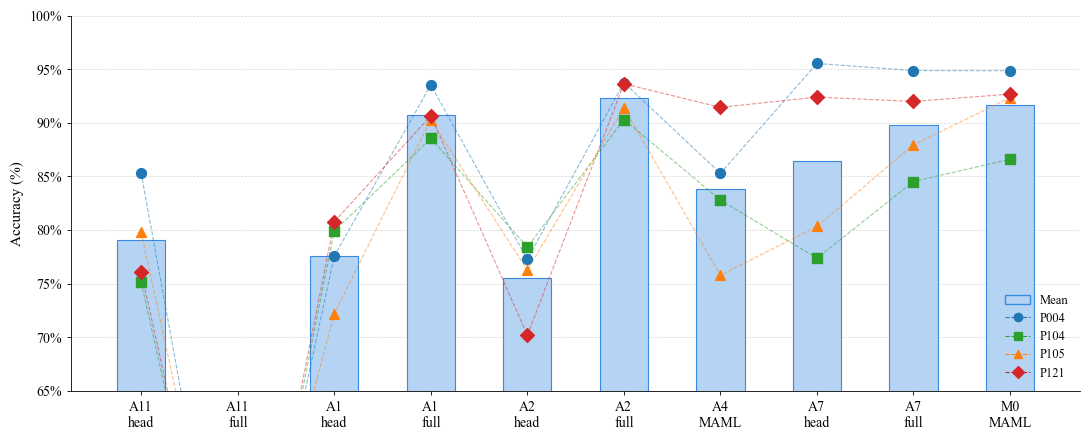

Saved fig1_main.pdf / .png


In [115]:
figure_main_ablations(df)


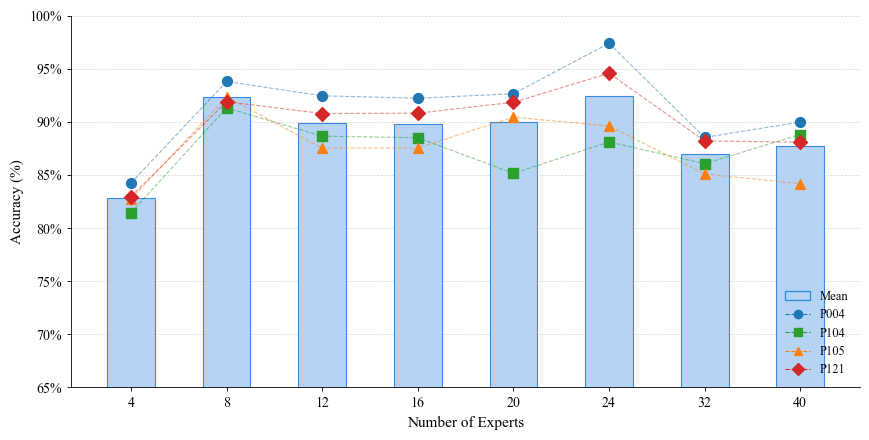

Saved fig2_experts.pdf / .png


In [116]:
figure_num_experts(df)


In [117]:

figure_grid(df)

AssertionError: Could not parse k/n from Ablation_ID: 'grid_A2_k1'

In [ ]:
# FIGURE: Main Figure: M0 vs Key Ablations
## This should probably be a table actually

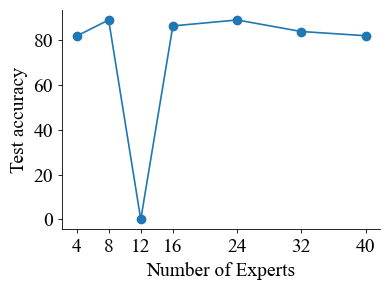

In [ ]:
# FIGURE: Num Experts Sweep (Line Plot)
## Ideally is a mountain curve around 22ish?

A5_num_experts_sweep_dict = {
    4: 81.80,   # (at 20 was 78.17...)
    8: 88.99,  # (at 20 was 89.42 lol)
    12: 0.0, 
    16: 86.34, 
    #20: 88.42, 
    24: 88.99, 32: 83.84, 40: 81.96, 
}

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13 + 1

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

ax.plot(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
    linewidth=1.2,
)
ax.scatter(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
)

ax.set_xticks(list(A5_num_experts_sweep_dict.keys()))
ax.set_xlabel("Number of Experts", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("num_experts_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("num_experts_sweep.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# FIGURE: K-shot N-way Performance Grid (Line Plot)
## Need to show best baseline here as well

In [26]:
# FIGURE: Eval Num Steps Sweep (Line Plot)
## I dont have error bars for this rn... maybe the json has the mean and std?

# A11 eval sweep (LR=0.01)
A11_eval_sweep_dict = {1: 37.60, 5: 49.93, 10: 64.29, 25: 78.47, 50: 81.08, 100: 81.44}  #, 150: 81.58, 200: 81.46}

# A7 eval sweep (LR=0.001)
# --> gonna ignore this one because it was not using paired corresponding user-specific models
A7_eval_sweep_dict = {1: 39.35, 5: 63.15, 10: 72.80, 25: 77.23, 50: 78.13, 100: 78.27, 150: 78.30, 200: 78.41}

# M0 eval sweep
M0_eval_sweep_dict = {1: 57.73, 5: 86.40, 10: 90.88, 25: 92.57, 50: 92.93, 100: 93.39} #, 150: 93.65}



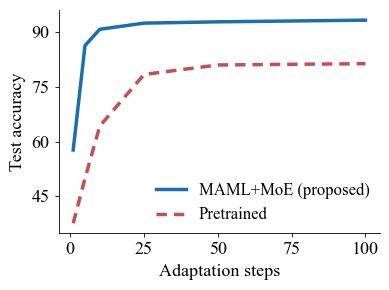

In [ ]:
COLORS = ["#1a6faf", "#2ca25f", "#c44e52"]
DASHES = [(), (6, 2), (3, 2)]

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

lines = [
    (M0_eval_sweep_dict,  "MAML+MoE (proposed)",         COLORS[0], DASHES[0]),
    #(A7_eval_sweep_dict,  "Subject-specific",   COLORS[1], DASHES[1]),
    (A11_eval_sweep_dict, "Pretrained", COLORS[2], DASHES[2]),
]

for data, label, color, dash in lines:
    ax.plot(
        list(data.keys()),
        list(data.values()),
        color=color,
        dashes=dash,
        label=label,
        linewidth=2.5,
    )

ax.set_xlabel("Adaptation steps", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="lower right", handlelength=1.8, borderaxespad=0.2, fontsize=LABEL_FONTSIZE-1)

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("eval_steps_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("eval_steps_sweep.png", dpi=500, bbox_inches="tight")
plt.show()